In [203]:
# add autoreload
%load_ext autoreload
%autoreload 2

import os, sys
from dotenv import load_dotenv

from timex.ecg import dataset, tokenizer

from tslearn.piecewise import OneD_SymbolicAggregateApproximation, SymbolicAggregateApproximation, PiecewiseAggregateApproximation
from fABBA import JABBA, fABBA

from torch.utils.data import DataLoader

from transformers import (
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    BigBirdForMaskedLM,
    BigBirdForPreTraining,
    BigBirdConfig
)

import numpy as np
np.set_printoptions(threshold=sys.maxsize)
import gc

from tqdm import tqdm

import matplotlib.pyplot as plt

load_dotenv('../.env')
BASE_DIR = os.getenv('ECG_DIR')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [204]:
nsegments = 128
SAX1d = OneD_SymbolicAggregateApproximation(n_segments=nsegments, alphabet_size_avg=300, alphabet_size_slope=300, 
                                            scale=False)
SAA = SymbolicAggregateApproximation(n_segments=nsegments, alphabet_size_avg=600, scale=False)

PAA = PiecewiseAggregateApproximation(n_segments=nsegments)

ABBA = JABBA(verbose=1, init='kmeans')

In [205]:
PREPLIST = ['savgol', 'resampler', 'notch', 'bandpass'] #, 'detrend', 'peak_trimming']

In [206]:
ECGDat = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                                       'records500',
                                       '00000'),
                       label_binarizer=None,
                       augmentations=[],                       
                       encode=False,
                       pretrain=False,
                       preprocessing=PREPLIST)

ECGDl_prep = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=ECGDat.collate)

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [207]:
# collect data for fitting
ecgConfig = dataset.Config
ecgConfig.SAMPLING_RATE = 500

results = []
for batch in tqdm(ECGDl_prep, desc="Processing ECG batches"):
    ecg_data, ecg_label, ecg_filenames, _ , ecg_metadata = batch
    for signal, label, metadata, filename in zip(ecg_data, ecg_label, ecg_metadata, ecg_filenames):
        results.append(np.array(signal).transpose())
results_concat = [r.ravel() for r in results]

Processing ECG batches: 100%|██████████| 8/8 [00:35<00:00,  4.41s/it]


In [34]:
print("Fitting SAA")
SAA.fit(results, y=None)

print("Fitting 1dSAX")
SAX1d.fit(results, y=None)

print("Fitting PAA")
PAA.fit(results, y=None)

print("Fitting ABBA")
ABBA.fit(np.vstack(results_concat[:5]), n_jobs=-1)

Fitting SAA
Fitting 1dSAX
Fitting PAA
Fitting ABBA
Generate 2 symbols


In [78]:
tl = 5000
sym_test = SAA.transform([results[0][:tl,:]])
inv_sym_test = SAA.inverse_transform(sym_test)[0]

sym_test_1d = SAX1d.transform([results[0][:tl,:]])
inv_sym_test_1d = SAX1d.inverse_transform(sym_test_1d)[0]

sym_test_paa = PAA.transform([results[0][:tl,:]])
inv_sym_test_paa = PAA.inverse_transform(sym_test_paa)[0]

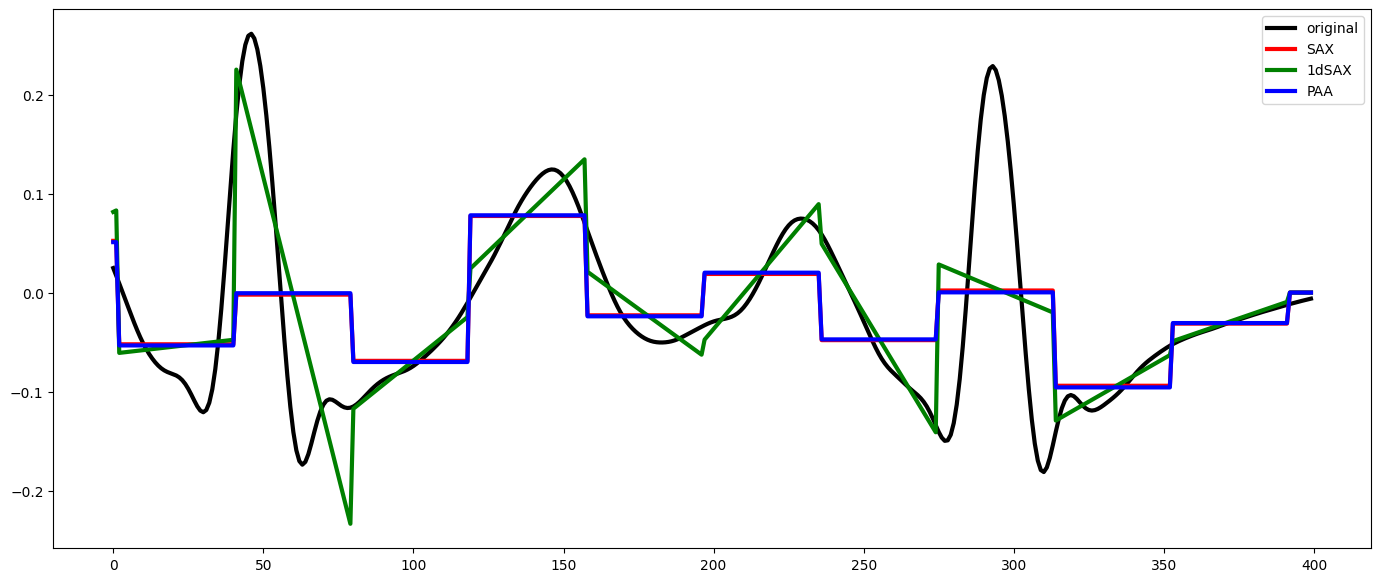

In [83]:
channel = 1
s = 4600
length = 512
b, e = s, s + length
fig,ax=plt.subplots(figsize=(17,7))
plt.plot(results[0][b:e, channel], color='black', lw=3, label='original')
plt.plot(inv_sym_test[b:e, channel], color='red', lw=3, label='SAX')
plt.plot(inv_sym_test_1d[b:e, channel], color='green', lw=3, label='1dSAX')
plt.plot(inv_sym_test_paa[b:e, channel], color='blue', lw=3, label='PAA')
plt.legend()

In [105]:
from scipy.signal import find_peaks

#Trimming first and last peaks/dips
def trim_signal(data):
    trimmed_signals_list = []
    for i in range(len(data)):
        for j in range(len(data[i])):
            peaks, _ = find_peaks(data[i][j], distance=30, prominence=(0.1))
            dips, _ = find_peaks(-data[i][j], distance=250)

            if len(peaks) == 0 or len(dips) == 0:
                trimmed_signals_list.append(data[i][j])
                continue

            first_peak = peaks[0] if len(peaks) > 0 else len(data[i][j])
            first_dip = dips[0] if len(dips) > 0 else len(data[i][j])

            start_index = min(first_peak, first_dip) if first_peak != len(data[i][j]) or first_dip != len(data[i][j]) else 0

            last_peak = peaks[-1] if len(peaks) > 0 else 0
            last_dip = dips[-1] if len(dips) > 0 else 0

            end_index = max(last_peak, last_dip) if last_peak != 0 or last_dip != 0 else len(data[i][j])
            if start_index >= end_index:
                trimmed_signals_list.append(data[i][j])
            else:
                trimmed_signals_list.append(data[i][j][start_index:end_index])

    try:
        trimmed_array = np.array(trimmed_signals_list)
    except ValueError:
        trimmed_array = np.array(trimmed_signals_list, dtype=object)

    return trimmed_array.reshape(len(data), 12,)    




In [208]:
result = np.array(results).reshape(len(results),len(results[0][0]),len(results[0]))
trimmed_array = trim_signal(result) #Shape:(n_signals, n_channels, ) inhomogeneous in third dimension

concatenated = np.concatenate([np.concatenate(row) for row in trimmed_array])
print(len(concatenated))


58668755


In [209]:
conc = concatenated.reshape(-1,1)  #For the sax fit

sax = SymbolicAggregateApproximation(n_segments= 100, alphabet_size_avg=300, scale=False)
sax_list = sax.fit(conc, y=None)
my_tokenizer = tokenizer.ECGTokenizer(SAX_List = sax_list)
encodings = my_tokenizer.encode(trimmed_array, symbolizer_model = 'sax')
print(encodings[0])

tok_ids = [encodings[i]["input_ids"] for i in range(len(encodings))]
#decoded = my_tokenizer._decode(tok_ids)
#print(decoded.shape)


987


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000260D3F65410>>
Traceback (most recent call last):
  File "c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.11\Lib\site-packages\ipykernel\ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


sax is done
reshape is done
11844
text is done ['[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', '[ ]', 

In [202]:
print(tok_ids[0])

tensor([0, 0, 3,  ..., 3, 3, 3])


In [84]:
ECGTok = tokenizer.ECGTokenizer(SAX_List=SAA)
ECGDc = DataCollatorForLanguageModeling(ECGTok, mlm=True)
ECGDl = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=ECGDc)

AttributeError: ECGTokenizer has no attribute SAX_List

In [27]:
model_config = BigBirdConfig.from_pretrained('google/bigbird-roberta-base')
model_config.bos_token_id = ECGTok.bos_token_id
model_config.eos_token_id = ECGTok.eos_token_id
model_config.pad_token_id = ECGTok.pad_token_id
model_config.cls_token_id = ECGTok.cls_token_id
model_config.sep_token_id = ECGTok.sep_token_id
model_config.mask_token_id = ECGTok.mask_token_id
model_config.vocab_size = ECGTok.vocab_size

print(f"Tokenizer vocab_size: {ECGTok.vocab_size}")
print(f"Special token IDs:")
print(f"  bos_token_id: {model_config.bos_token_id}")
print(f"  eos_token_id: {model_config.eos_token_id}")
print(f"  pad_token_id: {model_config.pad_token_id}")
print(f"  cls_token_id: {model_config.cls_token_id}")
print(f"  sep_token_id: {model_config.sep_token_id}")
print(f"  mask_token_id: {model_config.mask_token_id}")

RecursionError: maximum recursion depth exceeded while calling a Python object

In [ ]:
ECGModel = BigBirdForPreTraining(model_config)

In [ ]:
ECGTrainer = Trainer(model=)